## Imports

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

%load_ext autoreload
%autoreload all
from src.utils.eda_utils import (
    plot_target_distribution,
    plot_target_logtarget_distribution,
    plot_histogram,
    plot_numerical_vs_target,
)

COLOR_FONT = 'dimgray'
COLOR_PLOT = 'tan'

plt.style.use('../styles/presentation.mplstyle')

## Load the data

In [2]:
data = pd.read_csv('../data/processed/apartments_cleaned.csv')

## Identify outliers in `price`

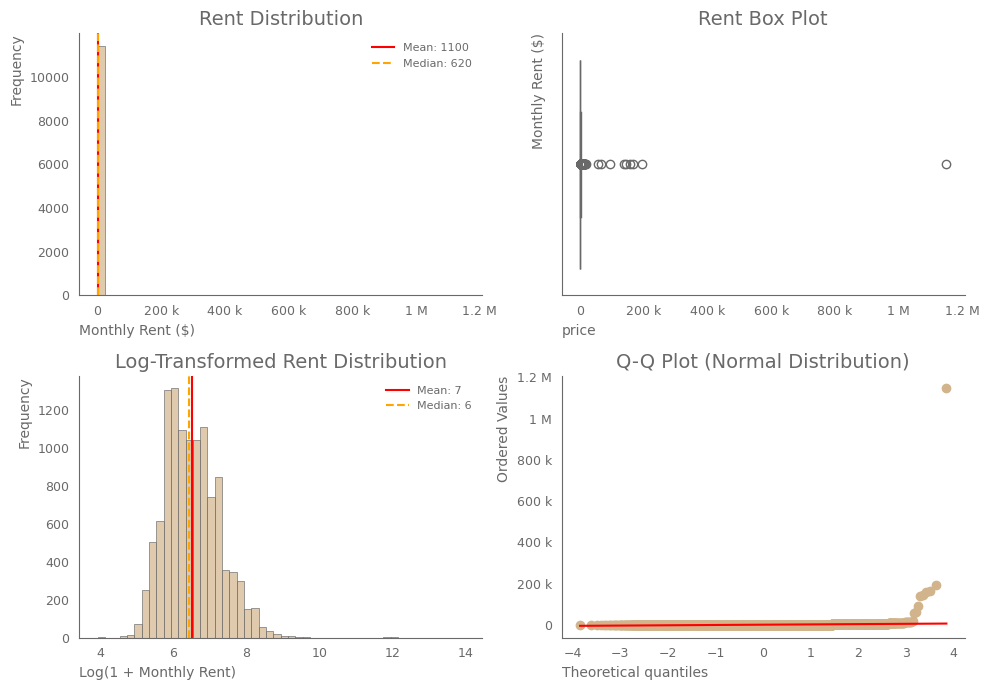

In [3]:
plot_target_distribution(data)

As observed in the exploratory data analysis, our target variable contains one extreme outlier (~1.15M) that significantly impacts the dispersion and distribution shape, masking the behavior of the majority of data points. While removing this top outlier slightly improves the distribution, it remains heavily right-skewed, with several other extreme values still present.

In fact, removing just one outlier is insufficient — there are at least 8 more large outliers (priced over $50K) that continue to distort the distribution and may violate key model assumptions.

To identify outliers more reliably, we incorporate additional information such as footage (area) and analyze anomalies in the combination of these features.


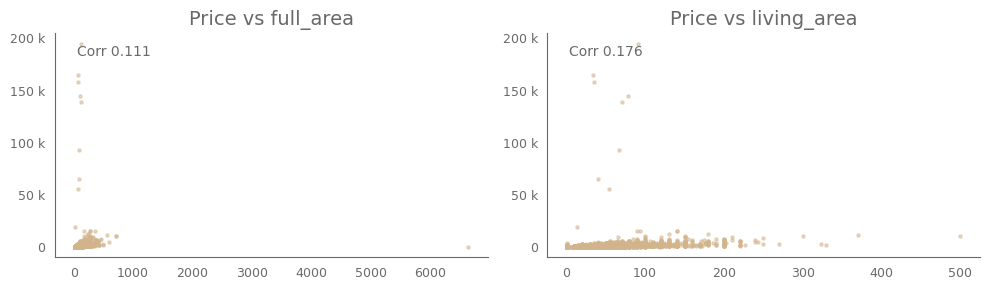

In [4]:
plot_numerical_vs_target(data[data['price'] < 1_000_000],
                         ['full_area', 'living_area'],
                         target_col='price',
                         filter_iqr=False)

In [5]:
data['price_per_sqft'] = data['price'] / data['full_area']

In [6]:
data['price_per_sqft'].describe()

count    11436.000000
mean        13.540399
std         63.973901
min          0.061794
25%          7.200000
50%         10.232558
75%         15.277778
max       5324.074074
Name: price_per_sqft, dtype: float64

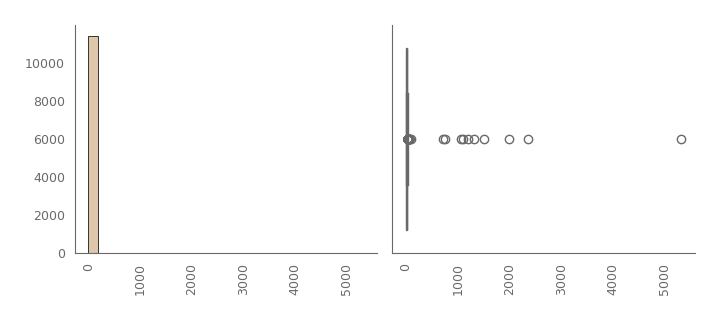

In [7]:
fig = plt.figure(figsize=(7, 3))

subfigs = fig.subfigures(nrows=2, ncols=1)
axs = fig.subplots(nrows=1, ncols=2)
sns.histplot(data['price_per_sqft'], ax=axs[0], bins=30, color=COLOR_PLOT)
sns.boxplot(data['price_per_sqft'], ax=axs[1], orient='h', color=COLOR_PLOT)
for ax in axs:
    ax.set(xlabel='', ylabel='')
    ax.tick_params('x', rotation=90)

plt.tight_layout()
plt.show()

Most `price_per_sqft` values are concentrated below 100, but several outliers exceed 1000, with some even reaching up to 5000. 

In [8]:
data['price_per_sqft'].sort_values()[-15:]

8141       55.319149
6667       55.555556
867        55.555556
6668       64.705882
10791      88.235294
8506      720.000000
1837      750.000000
5948     1055.555556
9540     1100.000000
9541     1200.000000
4204     1318.181818
4240     1500.000000
9050     2000.000000
11293    2357.142857
5523     5324.074074
Name: price_per_sqft, dtype: float64

In [9]:
data['price_per_sqft'].sort_values()[:15]

4047    0.061794
4035    0.882353
2116    0.916667
8051    1.052632
5484    1.224490
4029    1.470588
1108    1.600000
5485    1.617647
3150    1.714286
5266    2.000000
253     2.173913
4157    2.291667
3843    2.297297
1519    2.380952
852     2.407407
Name: price_per_sqft, dtype: float64

In [10]:
for idx in [4047, 4035, 2116]:
    print('\nidx:', idx, '\nprice:', data.loc[idx, 'price'])
    print('full_area:', data.loc[idx, 'full_area'])
    print('footage:', data.loc[idx, 'footage'])
    print(data.loc[idx, 'description'])



idx: 4047 
price: 410
full_area: 6635.0
footage: 6635 / 35 / 15 м²
Пропоную вашій увазі двокімнатну квартиру в ЖК Паркові озера по вул. Воскресенська 12а, 9/25, 66/35/13, укомплектована всіма необхідними меблями та побутовою технікою, нова кухня з посудомийною машиною, 2 шафи купе, спортивна стінка для дитини, лічильники на воду та тепло.
Територія, що охороняється, в якій 3 аптеки, безліч магазинів, садок, вихід з комплексу в парк Перемоги ціна-16500 грн

idx: 4035 
price: 60
full_area: 68.0
footage: 68 / 60 / 8 м²
м.Академгородок, или Теремки 15/ 20 минут. Сдам хорошую отдельную комнату, с удобной мебелью и бытовой техникой, за 2.500грн. + 500грн. коммунальные, в двухуровневой 3х ком квартире с современным ремонтом. В других двух комнатах проживает добродушная женщина с собачкой, часто не бывает дома. Комната по винтовой лестнице, на втором этаже квартиры, потолок как на фото. Комфортный ЖК " Львівський Маєток", с парковкой и зоной отдыха. Рядом АТБ, Фора, Новус, остановка прямой ма

In [11]:
data[data['price_per_sqft'] > 100]

,id,price,address,coordinates,region,subway,rooms,footage,floor,features,...,num_storeys,district,lon,lat,neighborhood_1,neighborhood_2,neighborhood_3,neighborhood_4,neighborhood_5,price_per_sqft
1837,11365267,55500,"Володимира Івсюка, 41","30.45631409,50.51047516","Київ,Оболонський р-н",NaN,4,74 / 54 / 7 м²,7,"['Стара цегла', 'Роздільне', 'Євроремонт']",...,12,Оболонський,30.456314,50.510475,Автозаводська,Пріорка,Вишгородський масив,NaN,NaN,750.000000
4204,11389707,145000,"Лейпцизька вул., 2/37","30.54609108,50.43452072","Київ,Печерський р-н",Печерська,4,110 / 78 / 9 м²,5,"['Сталінка', 'Суміжно-роздільна', 'Задовільний...",...,5,Печерський,30.546091,50.434521,Свято-Введенський монастир,Печерськ,Києво-Печерська лавра,NaN,NaN,1318.181818
4240,11411544,195000,"Андрія Верхогляда вул. (Драгомирова), 2","30.5462513,50.41396713","Київ,Печерський р-н",Звіринецька,6,130 / 91 / 19 м²,22,"['Українська цегла', 'Багаторівнева', 'Єврорем...",...,23,Печерський,30.546251,50.413967,Бусове поле,Новопечерські липки,NaN,NaN,NaN,1500.000000
5523,10951075,1150000,"Шевченка Тараса бульв., 11а","30.51571083,50.44249344","Київ,Шевченківський р-н",Театральна,4,216 / 130 / 15 м²,9,"['Суміжно-роздільна', 'Хороший стан']",...,15,Шевченківський,30.515711,50.442493,Парк ім. Шевченка,Бессарабка,Ботанічний сад ім. акад. О. В. Фоміна,NaN,NaN,5324.074074
5948,11397121,19000,"Мирослава Поповича вул. (Семашка), 8","30.36328125,50.46442413","Київ,Святошинський р-н",Академмістечко,1,18 / 13 / 4 м²,4,"['Українська цегла', 'Роздільне', 'Хороший стан']",...,5,Святошинський,30.363281,50.464424,Академмістечко,NaN,NaN,NaN,NaN,1055.555556
8506,11447061,64800,"Володимирська вул., 86А","30.508358,50.43465042","Київ,Голосіївський р-н",Олімпійська,3,90 / 40 / 35 м²,8,"['Бетонно монолітний', 'Суміжно-роздільна', 'Д...",...,17,Голосіївський,30.508358,50.434650,Паньківщина,Ботанічний сад ім. акад. О. В. Фоміна,NaN,NaN,NaN,720.000000
9050,11448712,158000,"Тверський тупик, 7-в","30.52968407,50.42428589","Київ,Печерський р-н",Печерська,2,79 / 35 / 25 м²,4,"['Бетонно монолітний', 'Суміжно-роздільна', 'Д...",...,23,Печерський,30.529684,50.424286,КНУКіМ,NaN,NaN,NaN,NaN,2000.000000
9540,11440249,93500,"Дегтярна вул., 29","30.50980377,50.45789719","Київ,Подільський р-н",Контрактова площа,2,85 / 67 / 18 м²,7,"['Бетонно монолітний', 'Роздільне', 'Дизайнерс...",...,8,Подільський,30.509804,50.457897,Пейзажна алея,Воздвиженка,Юрковиця,NaN,NaN,1100.000000
9541,11440122,139200,"Звіринецька вул., 59","30.55524063,50.40776825","Київ,Печерський р-н",Видубичі,3,116 / 70 / 17 м²,13,"['Бетонно монолітний', 'Роздільне', 'Дизайнерс...",...,14,Печерський,30.555241,50.407768,Новопечерські липки,Національний ботанічний сад ім. М. М. Гришка,NaN,NaN,NaN,1200.000000
11293,11431627,165000,"Богданівська вул., 7д","30.47681236,50.4349823","Київ,Солом'янський р-н",Вокзальна,3,70 / 34 / 18 м²,4,['Євроремонт'],...,24,Солом'янський,30.476812,50.434982,Солом'янка,Солом'янська площа,Кучмин яр,NaN,NaN,2357.142857


Upon inspection, we confirmed these are indeed true outliers and can be safely removed. Additionally, one apartment with an unusually low `price_per_sqft` was due to a data entry error — we corrected its `full_area` value accordingly.

These extreme values distort the overall scale and obscure meaningful patterns within the dense cluster of normal data points.

In [12]:
data.loc[4047, 'full_area'] = 66

The main cluster of properties falls below 200–250 in price per square feet, but several outliers extend up to 500+. To address this, we propose filtering out apartments with unrealistic price_per_sqft ratios. We define a reasonable range as:
- Lower bound: 0.5
- Upper bound: 100

Apartments falling outside this range will be excluded from the analysis.

In [13]:
def drop_outlier(df, lower_bound, upper_bound):
    df_clean = df.copy()
    df_clean['price_per_sqft'] = df_clean['price'] / df_clean['full_area']
    mask = (
        (df_clean['price_per_sqft'] >= lower_bound) &
        (df_clean['price_per_sqft'] <= upper_bound)
    )
    df_clean = df_clean[mask].drop(columns=['price_per_sqft'])

    return df_clean

In [14]:
data_cleaned = drop_outlier(data, lower_bound=0.5, upper_bound=100)

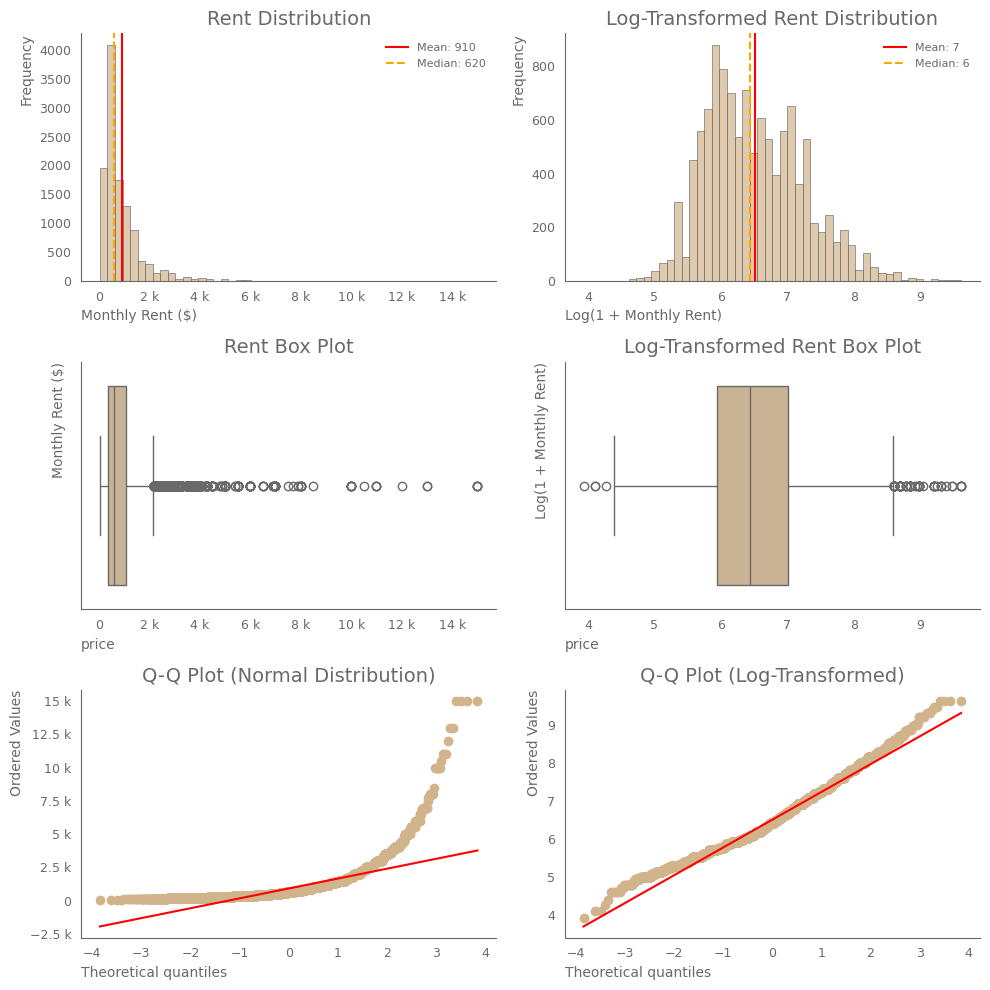

In [15]:
plot_target_logtarget_distribution(data_cleaned, column='price')

After outlier removal:
- The row rent still shows some skewness, but much reduced, and some outliers, but far fewer.
- The log-transformed rent has become approximately symmetric, indicating a more normal-like distribution with minimal outliers, suggesting good central tendency and spread.

So, outlier removal significantly improved the distribution, especially for modeling.

Log transformation + outlier removal leads to approximate normality, making the data more suitable for linear models and other parametric methods.

Raw rent remains somewhat skewed, so applying ML algorithms without transformation could lead to biased or unstable models.

## Split into train/test sets

For apartment rent prediction with a single model that performs well across both standard and luxury segments, we need to be ensure that our validation set includes proportional representation of both segments to get reliable performance estimates.

Since rent price is continuous, we can't directly use standard stratified sampling, but we could use binning-based stratification, dividing rent prices into bins (e.g., quartiles or deciles) and stratify based on these bins. This ensures both low and high-rent apartments are proportionally represented.

In [16]:
custom_bins = [
    0, 300, 450, 620, 900, 1300, 1800,
    2500, 3500, 5000, float('inf')
]
bin_labels = [
    'budget', 'affordable', 'mid_range', 'upper_mid', 'high_end',
    'premium', 'luxury', 'ultra_luxury', 'ultra_high', 'elite'
]

data_cleaned['price_bin'] = pd.cut(
    data_cleaned['price'],
    bins=custom_bins,
    labels=bin_labels,
    right=False,
    include_lowest=True)

In [17]:
(data_cleaned
    .groupby('price_bin', observed=True)[['price']]
    .agg(['count', 'mean', 'min', 'max'])
)


price                          
             count         mean   min    max
price_bin                                   
budget        1140   226.333333    50    290
affordable    2787   367.720488   300    440
mid_range     1636   518.656479   450    615
upper_mid     1963   724.069791   620    899
high_end      1615  1054.228483   900   1299
premium       1068  1454.907303  1300   1799
luxury         568  2029.920775  1800   2490
ultra_luxury   358  2776.117318  2500   3450
ultra_high     192  3863.932292  3500   4999
elite           99  7015.151515  5000  15000

In [18]:
df_train, df_test = train_test_split(
    data_cleaned, test_size=0.2,
    stratify=data_cleaned['price_bin'],
    random_state=7
)

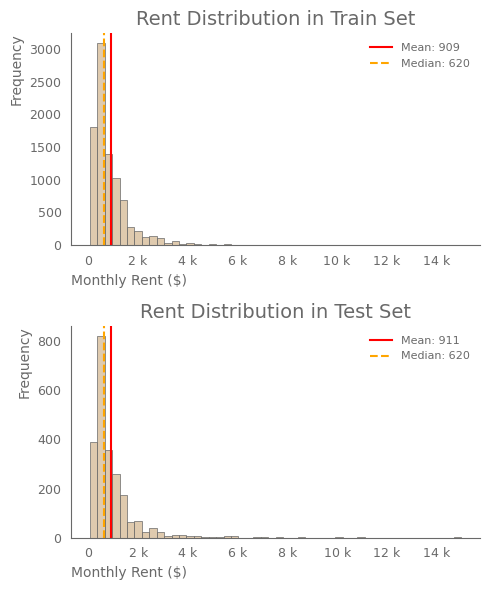

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(5, 6))
plot_histogram(axes[0], df_train['price'],
               title="Rent Distribution in Train Set",
               xlabel="Monthly Rent ($)",
               color=COLOR_PLOT)

plot_histogram(axes[1], df_test['price'],
               title="Rent Distribution in Test Set",
               xlabel="Monthly Rent ($)",
               color=COLOR_PLOT)
plt.tight_layout()
plt.show()

The train and test sets are well-stratified, with simalar distributions and nearly identical mean and median values.

In [20]:
df_train.to_csv('../data/processed/train_df.csv', index=False)
df_test.to_csv('../data/processed/test_df.csv', index=False)